# Regressão Linear Simples - Hospital Infection Data

## Análise de Risco de Infecção Hospitalar

**Baseado no material STAT 501 - Penn State University**

Este notebook ilustra os conceitos de avaliação de modelo de regressão linear simples (SLR) e estimação/predição, utilizando o dataset de infecção hospitalar.

## Parte 0: Configuração Inicial

Importação das bibliotecas necessárias e montagem do ambiente.

In [7]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Configuração para exibir todas as colunas ao imprimir DataFrames
pd.set_option('display.max_columns', None)

In [8]:
# Montagem do Google Drive (para uso no Colab)
from google.colab import drive
drive.mount('/content/drive')

# Caminho do arquivo de dados (ajuste conforme sua estrutura de pastas)
#dataset_path = '/content/drive/MyDrive/Datasets/hospitalinfct_reg1and2.txt'
dataset_path = '/content/drive/MyDrive/Colab_Notebooks/ACH2036_2026/datasets/hospitalinfct_reg1and2.txt'

# Alternativa para execução local (descomente se estiver rodando localmente)
# dataset_path = 'Datasets/hospitalinfct_reg1and2.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Parte 1: Carregamento e Análise Exploratória dos Dados

In [9]:
# Carregamento do dataset com limpeza dos nomes das colunas
df = pd.read_csv(dataset_path, sep='\t')

# Remover espaços em branco no início e fim dos nomes das colunas
df.columns = df.columns.str.strip()

# Visualização das primeiras linhas
print("Primeiras 5 observações:")
print(df.head())

# Verificar os nomes das colunas após a limpeza
print("\nNomes das colunas após limpeza:")
print(df.columns.tolist())

Primeiras 5 observações:
   ID   Stay   Age  InfctRsk  Culture   Xray  Beds  MedSchool  Region  Census  \
0   5  11.20  56.5       5.7     34.5   88.9   180          2       1     134   
1  10   8.84  56.3       6.3     29.6   82.6    85          2       1      59   
2  11  11.07  53.2       4.9     28.5  122.0   768          1       1     591   
3  13  12.78  56.8       7.7     46.0  116.9   322          1       1     252   
4  18  11.62  53.9       6.4     25.5   99.2   133          2       1     113   

   Nurses  Facilities  
0     151        40.0  
1      66        40.0  
2     656        80.0  
3     349        57.1  
4     101        37.1  

Nomes das colunas após limpeza:
['ID', 'Stay', 'Age', 'InfctRsk', 'Culture', 'Xray', 'Beds', 'MedSchool', 'Region', 'Census', 'Nurses', 'Facilities']


In [10]:
# Seleção das variáveis de interesse
# Y (resposta): InfctRsk - risco de infecção (% de pacientes que adquirem infecção)
# X (preditora): Stay - tempo médio de internação (em dias)

x = df['Stay']
y = df['InfctRsk']
n = len(df)

print(f"Número de observações: {n}")
print(f"\nResumo estatístico das variáveis de interesse:")
print(df[['Stay', 'InfctRsk']].describe())

Número de observações: 58

Resumo estatístico das variáveis de interesse:
           Stay   InfctRsk
count  58.00000  58.000000
mean   10.04931   4.556897
std     1.44107   1.305066
min     7.39000   1.300000
25%     8.90500   3.900000
50%     9.93000   4.500000
75%    11.06000   5.300000
max    13.95000   7.800000


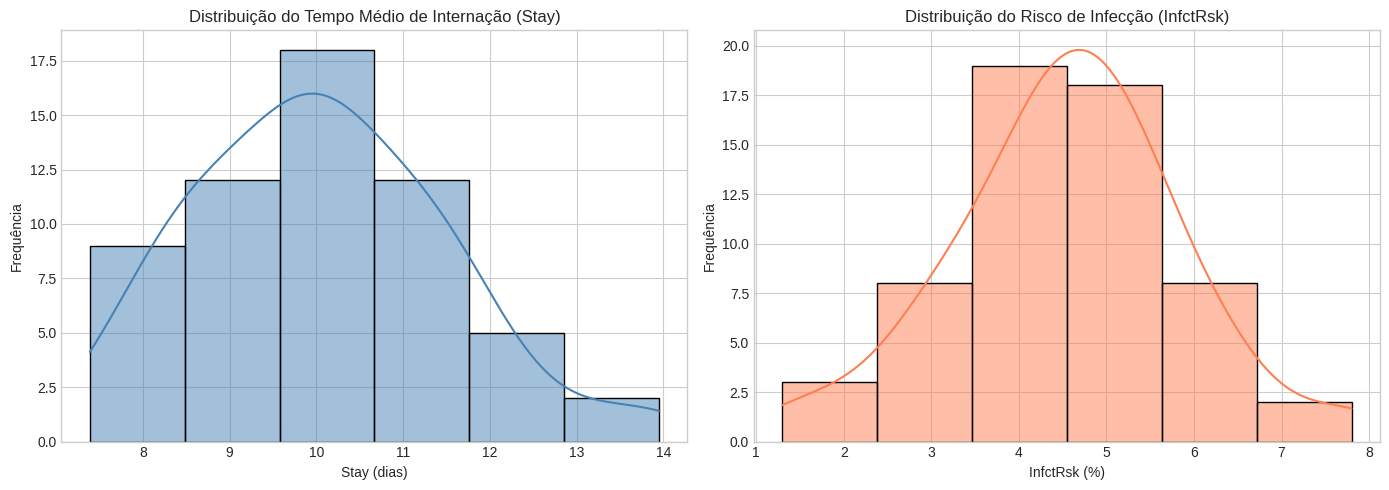

In [11]:
# Histogramas com densidade para as duas variáveis de interesse
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definindo o número de bins como n/10 (cada bin com ~10 observações)
bins = max(6, int(n/10))

# Histograma para Stay
sns.histplot(df['Stay'], bins=bins, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Tempo Médio de Internação (Stay)', fontsize=12)
axes[0].set_xlabel('Stay (dias)')
axes[0].set_ylabel('Frequência')

# Histograma para InfctRsk
sns.histplot(df['InfctRsk'], bins=bins, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuição do Risco de Infecção (InfctRsk)', fontsize=12)
axes[1].set_xlabel('InfctRsk (%)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## Partes 2 e 3: Ajuste do Modelo e Visualização da Relação

Agora vamos ajustar o modelo de regressão linear simples e visualizar a relação entre as variáveis.

In [12]:
# Ajuste do modelo usando statsmodels
modelo = smf.ols('InfctRsk ~ Stay', data=df).fit()

# Exibição do resumo completo
# print("=" * 70)
# print("RESUMO DO MODELO DE REGRESSÃO LINEAR SIMPLES")
# print("=" * 70)
print(modelo.summary())

# Extração dos coeficientes
b0 = modelo.params['Intercept']
b1 = modelo.params['Stay']

print(f"\nEquação da reta de regressão:")
print(f"InfctRsk = {b0:.4f} + {b1:.4f} * Stay")

                            OLS Regression Results                            
Dep. Variable:               InfctRsk   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.50
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.30e-07
Time:                        20:48:00   Log-Likelihood:                -82.684
No. Observations:                  58   AIC:                             169.4
Df Residuals:                      56   BIC:                             173.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1598      0.956     -1.213      0.2

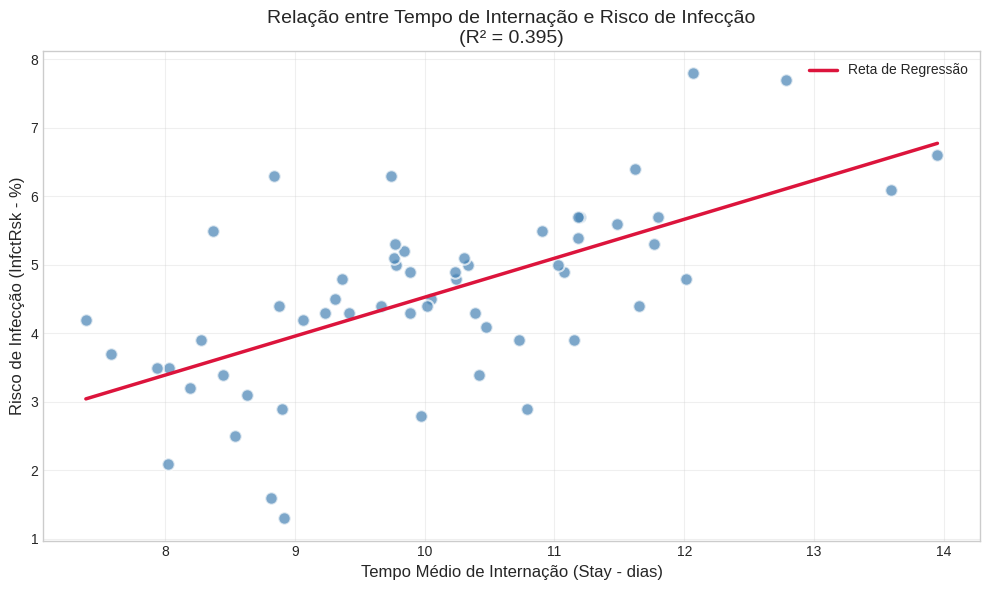

In [13]:
# Gráfico de dispersão com a reta de regressão
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot dos dados
ax.scatter(df['Stay'], df['InfctRsk'], alpha=0.7, s=80, color='steelblue', edgecolors='white', linewidth=1.5)

# Reta de regressão
x_range = np.linspace(df['Stay'].min(), df['Stay'].max(), 100)
y_pred = b0 + b1 * x_range
ax.plot(x_range, y_pred, color='crimson', linewidth=2.5, label='Reta de Regressão')

ax.set_xlabel('Tempo Médio de Internação (Stay - dias)', fontsize=12)
ax.set_ylabel('Risco de Infecção (InfctRsk - %)', fontsize=12)
ax.set_title(f'Relação entre Tempo de Internação e Risco de Infecção\n(R² = {modelo.rsquared:.3f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Parte 4: Inferência para o Slope (β₁)

O foco principal da avaliação do modelo é determinar se a relação linear observada é estatisticamente significativa.

In [14]:
# =============================================================================
# INFERÊNCIA PARA O SLOPE (β₁)
# =============================================================================

# Extração da tabela de coeficientes com intervalos de confiança
coef_table = modelo.summary().tables[1]
coef_df = pd.DataFrame(coef_table.data[1:], columns=coef_table.data[0])

# Cálculo dos intervalos de confiança (95%) usando o método conf_int()
ic_coef = modelo.conf_int(alpha=0.05)
ic_inf_b1 = ic_coef.loc['Stay', 0]
ic_sup_b1 = ic_coef.loc['Stay', 1]

print("=" * 70)
print("TABELA DE COEFICIENTES E INFERÊNCIA PARA O SLOPE (β₁)")
print("=" * 70)
print(coef_df.to_string(index=False))

print("\n" + "=" * 70)
print("INTERPRETAÇÃO DA INFERÊNCIA PARA O SLOPE (β₁)")
print("=" * 70)

print(f"""
1. Coeficiente estimado (b₁): {b1:.4f}
   - Para cada aumento de 1 dia no tempo médio de internação, o risco de infecção
     aumenta, em média, em {b1:.4f} pontos percentuais.

2. Erro Padrão (SE): {modelo.bse['Stay']:.4f}
   - Mede a precisão da estimativa do coeficiente.

3. Estatística t: {modelo.tvalues['Stay']:.2f}
   - Calculada como b₁ / SE(b₁). Quanto maior o valor absoluto, mais evidência
     contra a hipótese nula (β₁ = 0).

4. Valor-p: {modelo.pvalues['Stay']:.5f}
   - Probabilidade de obter um valor de t tão extremo quanto o observado,
     assumindo que a hipótese nula (β₁ = 0) é verdadeira.

5. Intervalo de Confiança (95%): [{ic_inf_b1:.4f}, {ic_sup_b1:.4f}]
   - Podemos afirmar, com 95% de confiança, que o verdadeiro aumento no risco
     de infecção para cada dia adicional de internação está entre {ic_inf_b1:.4f} e {ic_sup_b1:.4f}
     pontos percentuais.

6. Decisão: Como o intervalo NÃO contém o valor 0, rejeitamos a hipótese nula (β₁ = 0).
   Conclusão: Há uma relação linear estatisticamente significativa entre o tempo
   de internação (Stay) e o risco de infecção (InfctRsk) na população de hospitais.
""")

TABELA DE COEFICIENTES E INFERÊNCIA PARA O SLOPE (β₁)
                coef   std err         t  P>|t|    [0.025    0.975]
Intercept    -1.1598     0.956    -1.213  0.230    -3.075     0.755
     Stay     0.5689     0.094     6.041  0.000     0.380     0.757

INTERPRETAÇÃO DA INFERÊNCIA PARA O SLOPE (β₁)

1. Coeficiente estimado (b₁): 0.5689
   - Para cada aumento de 1 dia no tempo médio de internação, o risco de infecção
     aumenta, em média, em 0.5689 pontos percentuais.

2. Erro Padrão (SE): 0.0942
   - Mede a precisão da estimativa do coeficiente.

3. Estatística t: 6.04
   - Calculada como b₁ / SE(b₁). Quanto maior o valor absoluto, mais evidência
     contra a hipótese nula (β₁ = 0).

4. Valor-p: 0.00000
   - Probabilidade de obter um valor de t tão extremo quanto o observado,
     assumindo que a hipótese nula (β₁ = 0) é verdadeira.

5. Intervalo de Confiança (95%): [0.3802, 0.7575]
   - Podemos afirmar, com 95% de confiança, que o verdadeiro aumento no risco
     de infecção p

## Parte 5: Somas de Quadrados e Coeficiente de Determinação (R²)

Decomposição da variância total em partes explicada e não explicada pelo modelo.

In [15]:
# Cálculo manual das somas de quadrados
y_hat = modelo.fittedvalues
y_bar = y.mean()

SSTO = np.sum((y - y_bar)**2)  # Soma Total dos Quadrados
SSR = np.sum((y_hat - y_bar)**2)  # Soma dos Quadrados da Regressão
SSE = np.sum((y - y_hat)**2)  # Soma dos Quadrados dos Erros

# R²
r2 = modelo.rsquared
r2_adj = modelo.rsquared_adj

# Tabela ANOVA a partir do modelo (usando anova_lm do statsmodels)
from statsmodels.stats.anova import anova_lm
anova_table = anova_lm(modelo)

print("=" * 70)
print("SOMAS DE QUADRADOS")
print("=" * 70)
print(f"""
SSTO (Total)     = {SSTO:.4f}
SSR  (Regressão) = {SSR:.4f}
SSE  (Erro)      = {SSE:.4f}

Verificação: SSTO = SSR + SSE
  {SSTO:.4f} = {SSR:.4f} + {SSE:.4f}  →  {SSTO:.4f} = {SSR + SSE:.4f}  ✓
""")

print("\n" + "=" * 70)
print("TABELA ANOVA")
print("=" * 70)
print(anova_table)

print(f"""
COEFICIENTE DE DETERMINAÇÃO (R²):
  R²      = {r2:.4f}  → {r2*100:.2f}% da variação no risco de infecção
                          é explicada pelo tempo de internação.
  R²(adj) = {r2_adj:.4f}
""")

SOMAS DE QUADRADOS

SSTO (Total)     = 97.0822
SSR  (Regressão) = 38.3059
SSE  (Erro)      = 58.7763

Verificação: SSTO = SSR + SSE
  97.0822 = 38.3059 + 58.7763  →  97.0822 = 97.0822  ✓


TABELA ANOVA
            df     sum_sq    mean_sq          F        PR(>F)
Stay       1.0  38.305918  38.305918  36.496522  1.302453e-07
Residual  56.0  58.776324   1.049577        NaN           NaN

COEFICIENTE DE DETERMINAÇÃO (R²):
  R²      = 0.3946  → 39.46% da variação no risco de infecção
                          é explicada pelo tempo de internação.
  R²(adj) = 0.3838



## Parte 6: Estimação da Média (Intervalo de Confiança)

Estimativa da média do risco de infecção para hospitais com Stay = 10 dias.

In [16]:
# Novo ponto para estimação
x_h = 10

# Criando um DataFrame com o novo ponto
novo_dado = pd.DataFrame({'Stay': [x_h]})

# Obtendo previsão com intervalos
predicao = modelo.get_prediction(novo_dado)
pred_summary = predicao.summary_frame()

print("=" * 70)
print("ESTIMAÇÃO DA MÉDIA (INTERVALO DE CONFIANÇA)")
print("=" * 70)
print(f"""
Para hospitais com tempo médio de internação de {x_h} dias:

Valor estimado (ŷₕ): {pred_summary['mean'].iloc[0]:.4f}%
Erro Padrão do Ajuste (SE Fit): {pred_summary['mean_se'].iloc[0]:.4f}

INTERVALO DE CONFIANÇA (95%):
  [{pred_summary['mean_ci_lower'].iloc[0]:.5f}, {pred_summary['mean_ci_upper'].iloc[0]:.5f}]

Interpretação: Estamos 95% confiantes de que a média do risco de infecção para
hospitais com tempo médio de internação de {x_h} dias está entre
{pred_summary['mean_ci_lower'].iloc[0]:.4f}% e {pred_summary['mean_ci_upper'].iloc[0]:.4f}%.
""")

ESTIMAÇÃO DA MÉDIA (INTERVALO DE CONFIANÇA)

Para hospitais com tempo médio de internação de 10 dias:

Valor estimado (ŷₕ): 4.5288%
Erro Padrão do Ajuste (SE Fit): 0.1346

INTERVALO DE CONFIANÇA (95%):
  [4.25921, 4.79849]

Interpretação: Estamos 95% confiantes de que a média do risco de infecção para
hospitais com tempo médio de internação de 10 dias está entre
4.2592% e 4.7985%.



## Parte 7: Predição de uma Nova Observação (Intervalo de Predição)

Previsão do risco de infecção para um novo hospital específico com Stay = 10 dias.

In [17]:
print("=" * 70)
print("PREDIÇÃO DE UMA NOVA OBSERVAÇÃO (INTERVALO DE PREDIÇÃO)")
print("=" * 70)

print("=" * 70)
print("PREDIÇÃO PARA STAY = 10")
print("=" * 70)
print("\nTabela completa de predição:")
print(pred_summary.to_string())

print(f"""
Para um novo hospital específico com tempo médio de internação de {x_h} dias:

Valor previsto (ŷ): {pred_summary['mean'].iloc[0]:.4f}%

INTERVALO DE PREDIÇÃO (95%):
  [{pred_summary['obs_ci_lower'].iloc[0]:.5f}, {pred_summary['obs_ci_upper'].iloc[0]:.5f}]

Interpretação: Podemos afirmar, com 95% de confiança, que o risco de infecção
para um novo hospital específico com tempo médio de internação de {x_h} dias
estará entre {pred_summary['obs_ci_lower'].iloc[0]:.4f}% e {pred_summary['obs_ci_upper'].iloc[0]:.4f}%.
""")

PREDIÇÃO DE UMA NOVA OBSERVAÇÃO (INTERVALO DE PREDIÇÃO)
PREDIÇÃO PARA STAY = 10

Tabela completa de predição:
       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  4.528846  0.134602       4.259205       4.798486       2.45891      6.598781

Para um novo hospital específico com tempo médio de internação de 10 dias:

Valor previsto (ŷ): 4.5288%

INTERVALO DE PREDIÇÃO (95%):
  [2.45891, 6.59878]

Interpretação: Podemos afirmar, com 95% de confiança, que o risco de infecção
para um novo hospital específico com tempo médio de internação de 10 dias
estará entre 2.4589% e 6.5988%.



In [18]:
# Comparação visual entre CI e PI
print("=" * 70)
print("COMPARAÇÃO ENTRE INTERVALOS DE CONFIANÇA E PREDIÇÃO")
print("=" * 70)
print(f"""
Amplitude do IC (95%): {pred_summary['mean_ci_upper'].iloc[0] - pred_summary['mean_ci_lower'].iloc[0]:.4f}
Amplitude do IP (95%): {pred_summary['obs_ci_upper'].iloc[0] - pred_summary['obs_ci_lower'].iloc[0]:.4f}

CONCLUSÃO: O intervalo de predição é MAIS LARGO que o intervalo de confiança.
          Isso ocorre porque o IP considera tanto a incerteza na estimativa da média
          quanto a variabilidade natural dos dados individuais.
""")

COMPARAÇÃO ENTRE INTERVALOS DE CONFIANÇA E PREDIÇÃO

Amplitude do IC (95%): 0.5393
Amplitude do IP (95%): 4.1399

CONCLUSÃO: O intervalo de predição é MAIS LARGO que o intervalo de confiança.
          Isso ocorre porque o IP considera tanto a incerteza na estimativa da média
          quanto a variabilidade natural dos dados individuais.



## Parte 8: Visualização dos Intervalos de Confiança e Predição

Representação gráfica dos intervalos ao longo de toda a faixa dos dados.

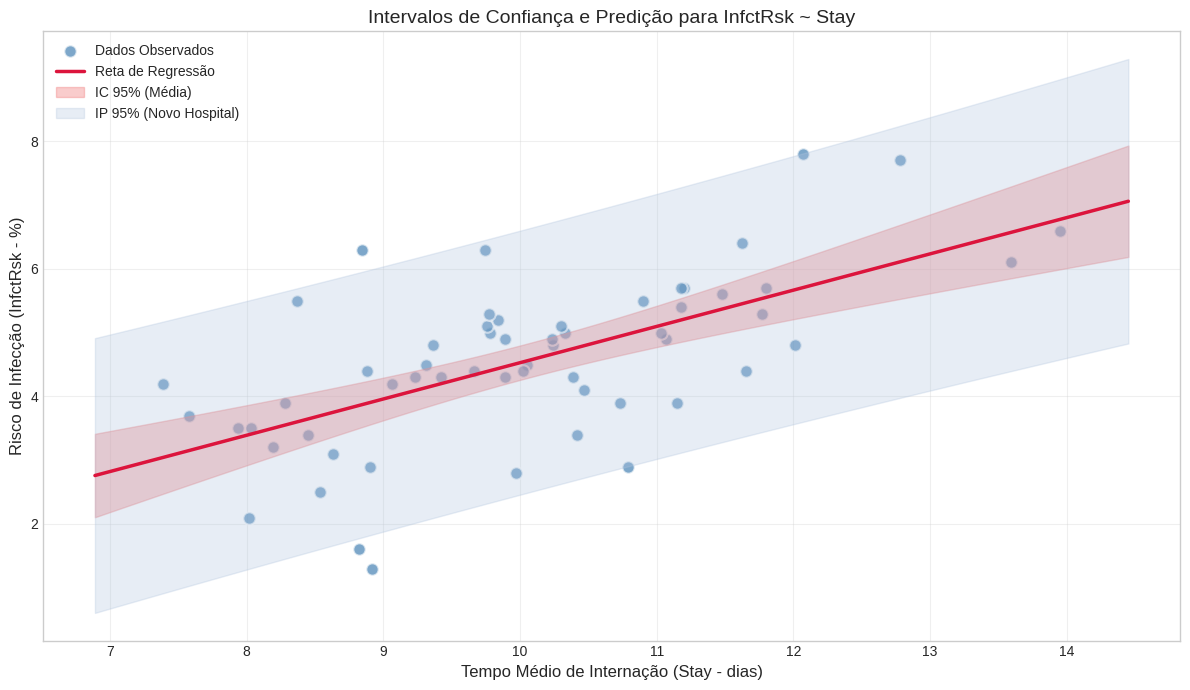

In [20]:
# Criação do grid de valores para visualização
x_grid = np.linspace(df['Stay'].min() - 0.5, df['Stay'].max() + 0.5, 100)
grid_df = pd.DataFrame({'Stay': x_grid})

# Obtendo previsões para todo o grid
pred_grid = modelo.get_prediction(grid_df)
pred_grid_summary = pred_grid.summary_frame()

# Criando o gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Dados observados
ax.scatter(df['Stay'], df['InfctRsk'], alpha=0.7, s=80,
          color='steelblue', edgecolors='white', linewidth=1.5, label='Dados Observados')

# Linha de regressão
ax.plot(x_grid, pred_grid_summary['mean'], color='crimson', linewidth=2.5, label='Reta de Regressão')

# Intervalo de Confiança (banda)
ax.fill_between(x_grid,
                pred_grid_summary['mean_ci_lower'],
                pred_grid_summary['mean_ci_upper'],
                color='lightcoral', alpha=0.4, label='IC 95% (Média)')

# Intervalo de Predição (banda)
ax.fill_between(x_grid,
                pred_grid_summary['obs_ci_lower'],
                pred_grid_summary['obs_ci_upper'],
                color='lightsteelblue', alpha=0.3, label='IP 95% (Novo Hospital)')

# Destaque para x_h = 10
# ax.axvline(x=10, color='darkgreen', linestyle='--', alpha=0.7, label='Stay = 10 dias')

ax.set_xlabel('Tempo Médio de Internação (Stay - dias)', fontsize=12)
ax.set_ylabel('Risco de Infecção (InfctRsk - %)', fontsize=12)
ax.set_title('Intervalos de Confiança e Predição para InfctRsk ~ Stay', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()